## Black Friday Dataset EDA and Feture Engineering
### Preparing the data for model training

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler

In [17]:
df = pd.read_csv("train.csv")
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [18]:
df_test = pd.read_csv("test.csv")
df_test.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


In [19]:
#concating both datasets
df_final = pd.concat([df,df_test]) 
df_final.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [20]:
#dropping unnecessary columns
df_final.drop(["User_ID"], axis=1, inplace=True)

In [21]:
df_final.shape

(783667, 11)

In [22]:
df_final.info()
df_final.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 783667 entries, 0 to 233598
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      783667 non-null  object 
 2   Age                         783667 non-null  object 
 3   Occupation                  783667 non-null  int64  
 4   City_Category               783667 non-null  object 
 5   Stay_In_Current_City_Years  783667 non-null  object 
 6   Marital_Status              783667 non-null  int64  
 7   Product_Category_1          783667 non-null  int64  
 8   Product_Category_2          537685 non-null  float64
 9   Product_Category_3          237858 non-null  float64
 10  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 71.7+ MB


,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [23]:
#handling Categorical feature gender
df_final["Gender"]= df_final["Gender"].map({"F":0,"M":1})
df_final.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [24]:
df_final["Age"].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [25]:
#now handling categorical feature age
df_final["Age"] = df_final["Age"].map({'0-17':1,'18-25':2,'26-35':3,'36-45':4,'46-50':5,'51-55':6,'55+':7})
df_final.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,1,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,1,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,1,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,7,16,C,4+,0,8,NaN,NaN,7969.0


In [26]:
#now handling categorical feature City Category 
df_city = pd.get_dummies(df_final["City_Category"], drop_first=True).astype(int)
df_city

,B,C
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1
...,...,...
233594,1,0
233595,1,0
233596,1,0
233597,0,1


In [27]:
df  = pd.concat([df_final, df_city], axis=1 )
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,A,2,0,3,NaN,NaN,8370.0,0,0
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,A,2,0,12,NaN,NaN,1422.0,0,0
3,P00085442,0,1,10,A,2,0,12,14.0,NaN,1057.0,0,0
4,P00285442,1,7,16,C,4+,0,8,NaN,NaN,7969.0,0,1


In [28]:
df.drop(["City_Category"],axis=1 ,inplace=True)
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,NaN,NaN,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,2,0,12,NaN,NaN,1422.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,NaN,1057.0,0,0
4,P00285442,1,7,16,4+,0,8,NaN,NaN,7969.0,0,1


In [29]:
#checking missing values
df.info()
df.isnull().sum()
df.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 783667 entries, 0 to 233598
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  object 
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          537685 non-null  float64
 8   Product_Category_3          237858 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  int32  
 11  C                           783667 non-null  int32  
dtypes: float64(3), int32(2), int64(5), object(2)
memory usage: 71.7+ MB


(783667, 12)

In [30]:
#handling missing values
df["Product_Category_2"].value_counts()

8.0     91317
14.0    78834
2.0     70498
16.0    61687
15.0    54114
5.0     37165
4.0     36705
6.0     23575
11.0    20230
17.0    19104
13.0    15054
9.0      8177
12.0     7801
10.0     4420
3.0      4123
18.0     4027
7.0       854
Name: Product_Category_2, dtype: int64

In [31]:
df["Product_Category_2"].mode()

0    8.0
dtype: float64

In [32]:
#replacing missing values with mode
df["Product_Category_2"]= df["Product_Category_2"].fillna(df["Product_Category_2"].mode()[0])

In [33]:
df["Product_Category_2"].isnull().sum()

0

In [34]:
df["Product_Category_3"].unique()

array([nan, 14., 17.,  5.,  4., 16., 15.,  8.,  9., 13.,  6., 12.,  3.,
       18., 11., 10.])

In [35]:
df["Product_Category_3"].mode()

0    16.0
dtype: float64

In [36]:
df["Product_Category_3"]= df["Product_Category_3"].fillna(df["Product_Category_3"].mode()[0])

In [37]:
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,8.0,16.0,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,2,0,12,8.0,16.0,1422.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,16.0,1057.0,0,0
4,P00285442,1,7,16,4+,0,8,8.0,16.0,7969.0,0,1


In [38]:
df.drop("Stay_In_Current_City_Years",axis=1,inplace=True)

In [39]:
df.head()

,Product_ID,Gender,Age,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,0,3,8.0,16.0,8370.0,0,0
1,P00248942,0,1,10,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,0,12,8.0,16.0,1422.0,0,0
3,P00085442,0,1,10,0,12,14.0,16.0,1057.0,0,0
4,P00285442,1,7,16,0,8,8.0,16.0,7969.0,0,1


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 783667 entries, 0 to 233598
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Product_ID          783667 non-null  object 
 1   Gender              783667 non-null  int64  
 2   Age                 783667 non-null  int64  
 3   Occupation          783667 non-null  int64  
 4   Marital_Status      783667 non-null  int64  
 5   Product_Category_1  783667 non-null  int64  
 6   Product_Category_2  783667 non-null  float64
 7   Product_Category_3  783667 non-null  float64
 8   Purchase            550068 non-null  float64
 9   B                   783667 non-null  int32  
 10  C                   783667 non-null  int32  
dtypes: float64(3), int32(2), int64(5), object(1)
memory usage: 65.8+ MB


<AxesSubplot:xlabel='Age', ylabel='Purchase'>

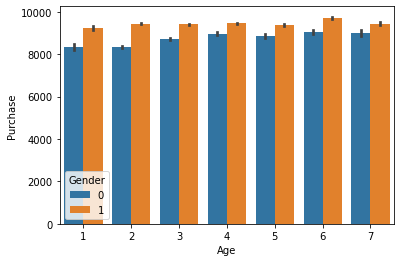

In [41]:
## who has bought most amount of goods
sns.barplot(x ="Age",y = "Purchase" ,hue="Gender",data=df)

 Obesrvation:  Quite surprisingly Men bought more than women


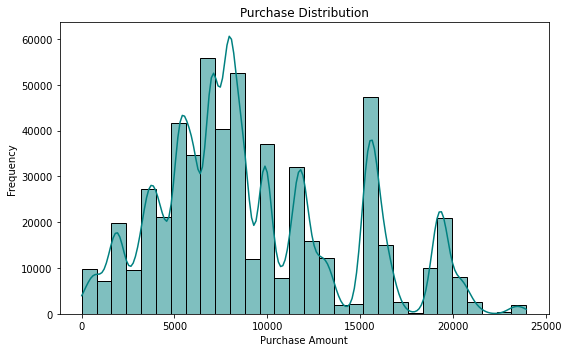

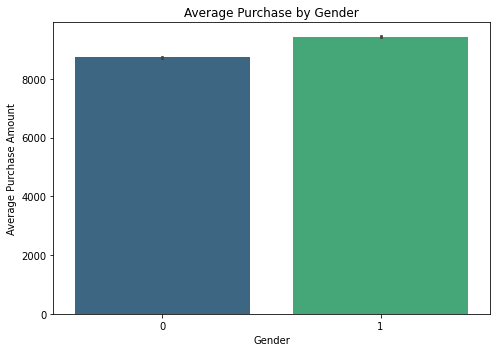

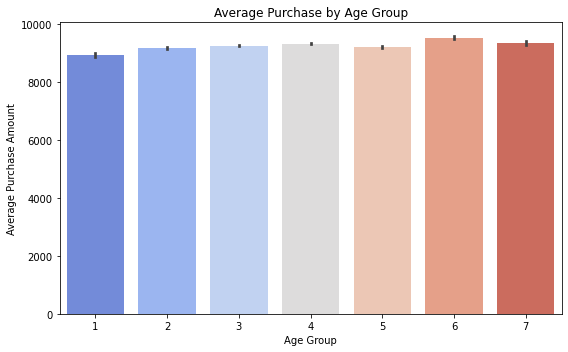

In [75]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
os.makedirs("images", exist_ok=True)
# Purchase Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Purchase'], bins=30, kde=True, color='teal')
plt.title("Purchase Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("images/purchase_distribution.png")
plt.show()


plt.figure(figsize=(7,5))
sns.barplot(x='Gender', y='Purchase', data=df, estimator=np.mean, palette='viridis')
plt.title("Average Purchase by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase Amount")
plt.tight_layout()
plt.savefig("images/gender_vs_purchase.png")
plt.show()


plt.figure(figsize=(8,5))
sns.barplot(x='Age', y='Purchase', data=df, estimator=np.mean, palette='coolwarm')
plt.title("Average Purchase by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount")
plt.tight_layout()
plt.savefig("images/age_vs_purchase.png")
plt.show()


<AxesSubplot:xlabel='Product_Category_1', ylabel='Purchase'>

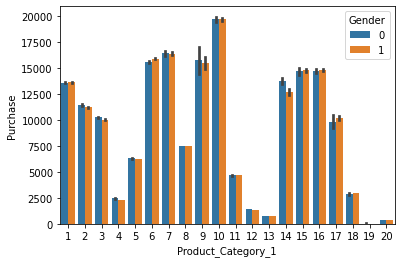

In [76]:
# Now checking which category has been bought the most
sns.barplot(x ="Product_Category_1",y = "Purchase" ,hue="Gender",data=df)

<AxesSubplot:xlabel='Product_Category_2', ylabel='Purchase'>

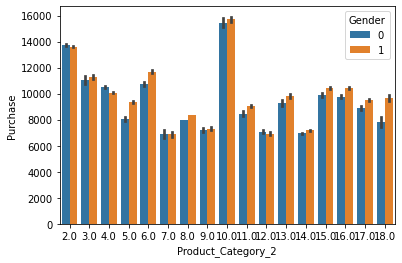

In [77]:
sns.barplot(x ="Product_Category_2",y = "Purchase" ,hue="Gender",data=df)

<AxesSubplot:xlabel='Product_Category_3', ylabel='Purchase'>

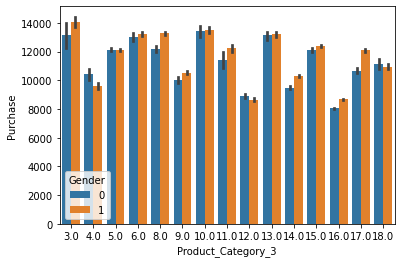

In [78]:
sns.barplot(x ="Product_Category_3",y = "Purchase" ,hue="Gender",data=df)

Observation: Product category 1 has sold more than other two categories

In [80]:
#splitting training and testing Data
df_test = df[df["Purchase"].isnull()]
df_train = df[~df["Purchase"].isnull()]

In [81]:
X = df_train.drop(["Purchase"],axis=1)
y = df_train["Purchase"]


model = LinearRegression()
sc = StandardScaler()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [82]:
X_train.drop(["Product_ID"],axis=1,inplace=True)
X_test.drop(["Product_ID"],axis=1,inplace=True)

## feature scaling

sc = StandardScaler()
X_train =sc.fit_transform(X_train)
X_test = sc.transform(X_test)

C:\Users\ranaa\anaconda3\envs\boooksenv\lib\site-packages\pandas\core\frame.py:4174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


# Linear Regression

In [83]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results:
MAE: 3575.5358222084224
RMSE: 4674.407133844804
R2 Score: 0.13038583259231085


Observation: linear regression is not the best fit for this dataset Black Friday purchase behavior is highly nonlinear now we will try other algorithms

# DecisionTreeRegressor

In [91]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Decision Tree model
dt = DecisionTreeRegressor(max_depth=15, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluation metrics
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

# Print results
print("Decision Tree Results:")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results:
MAE: 2229.439983681936
RMSE: 2995.8625155638233
R2 Score: 0.642795194819328


# Random Forest Regressor

In [84]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_split=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rrmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rr2 = r2_score(y_test, y_pred_rf)
rmae = mean_absolute_error(y_test, y_pred_rf)
print("Random Forest Results:")
print("MAE:",rmae)
print("RMSE:", rrmse)
print("R2:", rr2)


Random Forest Results:
MAE: 2199.6711300314337
RMSE: 2942.109203229864
R2: 0.6554985046392133


# XGBoost Regressor

In [98]:

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=800, learning_rate=0.5, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xrmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xr2 = r2_score(y_test, y_pred_xgb)
xmae = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost Results:")
print("MAE:", xmae)
print("RMSE:", xrmse)
print("R2:", xr2)


XGBoost Results:
MAE: 2190.09839259145
RMSE: 2942.095026926766
R2: 0.6555018245335562


In [99]:
models = pd.DataFrame({
    "Models": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "MAE": [mae, mae_dt, rmae, xmae],
    "RMSE": [rmse, rmse_dt, rrmse, xrmse],
    "R2 Score": [r2, r2_dt, rr2, xr2]
})

models

,Models,MAE,RMSE,R2 Score
0,Linear Regression,3575.535822,4674.407134,0.130386
1,Decision Tree,2229.439984,2995.862516,0.642795
2,Random Forest,2199.671130,2942.109203,0.655499
3,XGBoost,2190.098393,2942.095027,0.655502


In [112]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

def train_model():
    # 1. Load the dataset
    df = pd.read_csv("Data/train.csv")

    # 2. Data Cleaning (Handling Nulls)
    # Filling missing categories with 0 as you did in your notebook
    df['Product_Category_2'] = df['Product_Category_2'].fillna(0).astype('int64')
    df['Product_Category_3'] = df['Product_Category_3'].fillna(0).astype('int64')

    # 3. Feature Engineering (Encoding)
    encoders = {}
    for col in ['Gender', 'Age', 'City_Category']:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le # We save these to encode user input in the app later

    # One-hot encoding for Stay_In_Current_City_Years
    df = pd.get_dummies(df, columns=['Stay_In_Current_City_Years'])

    # 4. Feature Selection
    # Dropping non-predictive IDs and the target variable
    X = df.drop(["Purchase", "User_ID", "Product_ID"], axis=1)
    y = df['Purchase']

    # 5. Model Training
    # Using the XGBoost parameters you found were best (RMSE ~2879)
    model = XGBRegressor(learning_rate=1.0, max_depth=6, min_child_weight=40, seed=0)
    model.fit(X, y)

    # 6. Serialization (Saving the "Brain")
    model.save_model("black_friday_model.json")
    joblib.dump(encoders, 'encoders.pkl')
    joblib.dump(X.columns.tolist(), 'model_columns.pkl')
    
    print("Training Complete. Model and Encoders saved!")

if __name__ == "__main__":
    train_model()

Training Complete. Model and Encoders saved!


In [110]:
# import pandas as pd
# import joblib
# from xgboost import XGBRegressor
# from sklearn.model_selection import train_test_split

# # Load dataset
# df = pd.read_csv("Data/train.csv")

# # 1. Basic Cleaning
# df['Product_Category_2'] = df['Product_Category_2'].fillna(0).astype(int)
# df['Product_Category_3'] = df['Product_Category_3'].fillna(0).astype(int)
# df.drop(["User_ID", "Product_ID"], axis=1, inplace=True)

# # 2. Manual Mapping (Ensures the App uses the same numbers as the Model)
# gender_map = {'F': 0, 'M': 1}
# age_map = {'0-17': 0, '18-25': 1, '26-35': 2, '36-45': 3, '46-50': 4, '51-55': 5, '55+': 6}
# city_map = {'A': 0, 'B': 1, 'C': 2}
# stay_map = {'0': 0, '1': 1, '2': 2, '3': 3, '4+': 4}

# df['Gender'] = df['Gender'].map(gender_map)
# df['Age'] = df['Age'].map(age_map)
# df['City_Category'] = df['City_Category'].map(city_map)
# df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].map(stay_map)

# # 3. Features and Target
# X = df.drop("Purchase", axis=1)
# y = df['Purchase']

# # 4. Training the best model found in your notebook
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
# model = XGBRegressor(learning_rate=0.1, max_depth=6, n_estimators=100)
# model.fit(X_train, y_train)

# # 5. Save the Model
# model.save_model("black_friday_model.json")
# print("Model trained and saved as black_friday_model.pkl")

Model trained and saved as black_friday_models.pkl
